# Garbage Classification — ResNet18 Hyperparameter Tuning

새 EDA의 고정 분할과 **증강 미적용** 조건에서 ResNet18의 학습률과 weight decay를 비교합니다.

- 기존 `ResNet18_NoAug` (`lr=1e-4`, `weight_decay=0`) 결과를 기준으로 재사용합니다.
- 새 후보는 `lr=5e-5`, `lr=1e-5`, `lr=5e-5 + weight_decay=1e-4`입니다.
- 모든 후보는 동일한 ImageNet 가중치, seed, 데이터 분할, 최대 epoch와 Early Stopping을 사용합니다.
- 설정 선택은 Validation Macro F1만 사용합니다.
- Test는 최종 설정을 확정한 후 마지막에 한 번만 평가합니다.


In [1]:
# 패키지가 없을 때만 주석을 해제하여 한 번 실행하세요.
# %pip install torch torchvision pandas numpy scikit-learn matplotlib seaborn pillow tqdm


In [2]:
from pathlib import Path
import json, random, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True


## 1. 공통 설정

사전학습 ResNet18은 빠르게 수렴하므로 최대 30 epoch로 두고, Validation Macro F1이 6회 연속 개선되지 않으면 조기 종료합니다.


In [3]:
SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 30
PATIENCE = 6

PROJECT_DIR = Path.cwd()
RESULT_DIR = PROJECT_DIR / 'results'
CHECKPOINT_DIR = PROJECT_DIR / 'checkpoints'
RESULT_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(exist_ok=True)

TRAIN_CSV = PROJECT_DIR / 'train_metadata_final.csv'
VAL_CSV = PROJECT_DIR / 'val_metadata_final.csv'
TEST_CSV = PROJECT_DIR / 'test_metadata_final.csv'
BASELINE_CHECKPOINT = CHECKPOINT_DIR / 'ResNet18_NoAug_best.pth'
for path in (TRAIN_CSV, VAL_CSV, TEST_CSV, BASELINE_CHECKPOINT):
    assert path.exists(), f'필수 파일이 없습니다: {path}'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('project:', PROJECT_DIR)
print('device :', device)
if device.type == 'cuda': print('GPU    :', torch.cuda.get_device_name(0))


project: c:\Users\KDS-30\Desktop\Projects\04_Team_Projcet3
device : cuda
GPU    : NVIDIA GeForce RTX 5060 Laptop GPU


In [4]:
def reset_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

reset_seed()


## 2. 고정 분할 로드와 누수 검증

기존 실험에서 확정한 CSV를 그대로 사용하며, 이 노트북에서는 데이터를 다시 분할하지 않습니다.


In [5]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

def resolve_path(value):
    p = Path(str(value).replace('\\','/'))
    return p if p.is_absolute() else PROJECT_DIR / p

for frame in (train_df, val_df, test_df):
    frame['resolved_path'] = frame['path'].map(resolve_path)
    assert frame['resolved_path'].map(Path.exists).all()

class_names = sorted(train_df.class_name.unique())
class_to_idx = {name:i for i,name in enumerate(class_names)}
idx_to_class = {i:name for name,i in class_to_idx.items()}
NUM_CLASSES = len(class_names)

tg, vg, sg = map(lambda d:set(d.split_group), (train_df,val_df,test_df))
assert tg.isdisjoint(vg) and tg.isdisjoint(sg) and vg.isdisjoint(sg)
assert all(set(d.class_name)==set(class_names) for d in (train_df,val_df,test_df))
print(f'Train {len(train_df):,} / Validation {len(val_df):,} / Test {len(test_df):,}')
print('split_group 누수 없음 / 모든 분할에 12개 클래스 존재')


Train 10,842 / Validation 2,322 / Test 2,322
split_group 누수 없음 / 모든 분할에 12개 클래스 존재


## 3. 증강 미적용 Dataset

학습률과 weight decay의 영향만 비교하기 위해 모든 후보에서 동일한 결정적 변환을 사용합니다.


In [6]:
eval_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(IMAGE_SIZE), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class GarbageDataset(Dataset):
    def __init__(self, frame): self.frame=frame.reset_index(drop=True)
    def __len__(self): return len(self.frame)
    def __getitem__(self, i):
        row=self.frame.iloc[i]
        with Image.open(row.resolved_path) as im: x=eval_transform(im.convert('RGB'))
        return x, class_to_idx[row.class_name], str(row.resolved_path)

def make_loaders(seed=SEED):
    common=dict(batch_size=BATCH_SIZE,num_workers=NUM_WORKERS,pin_memory=(device.type=='cuda'))
    g=torch.Generator().manual_seed(seed)
    return (DataLoader(GarbageDataset(train_df),shuffle=True,generator=g,**common),
            DataLoader(GarbageDataset(val_df),shuffle=False,**common),
            DataLoader(GarbageDataset(test_df),shuffle=False,**common))

train_loader, val_loader, test_loader = make_loaders()
x,y,_=next(iter(train_loader))
print(x.shape,y.shape)


torch.Size([32, 3, 224, 224]) torch.Size([32])


## 4. ResNet18 및 평가 함수

In [7]:
class ResNet18(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network=models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        n=self.network.fc.in_features
        self.network.fc=nn.Sequential(nn.Dropout(0.3),nn.Linear(n,num_classes))
    def forward(self,x): return self.network(x)

def evaluate(model,loader,criterion=None):
    model.eval(); loss_sum=0.; ys=[]; preds=[]; probs=[]; paths=[]
    with torch.inference_mode():
        for x,y,p in tqdm(loader,leave=False):
            x=x.to(device,non_blocking=True); yd=y.to(device,non_blocking=True)
            logits=model(x)
            if criterion is not None: loss_sum += criterion(logits,yd).item()*len(y)
            prob=torch.softmax(logits,1).cpu().numpy()
            ys.extend(y.numpy()); preds.extend(prob.argmax(1)); probs.extend(prob); paths.extend(p)
    ys=np.asarray(ys); preds=np.asarray(preds); probs=np.asarray(probs)
    return {'loss':loss_sum/len(loader.dataset) if criterion else None,
            'accuracy':accuracy_score(ys,preds),'balanced_accuracy':balanced_accuracy_score(ys,preds),
            'macro_f1':f1_score(ys,preds,average='macro',zero_division=0),
            'targets':ys,'preds':preds,'probs':probs,'paths':paths}

def train_epoch(model,loader,criterion,optimizer):
    model.train(); loss_sum=0.; ys=[]; preds=[]
    for x,y,_ in tqdm(loader,leave=False):
        x=x.to(device,non_blocking=True); y=y.to(device,non_blocking=True)
        optimizer.zero_grad(set_to_none=True); logits=model(x); loss=criterion(logits,y)
        loss.backward(); optimizer.step()
        loss_sum += loss.item()*len(y); ys.extend(y.cpu().numpy()); preds.extend(logits.argmax(1).detach().cpu().numpy())
    return {'loss':loss_sum/len(loader.dataset),'accuracy':accuracy_score(ys,preds),
            'macro_f1':f1_score(ys,preds,average='macro',zero_division=0)}


## 5. 기존 기준 모델 평가

이미 완료된 `lr=1e-4, weight_decay=0` 최고 체크포인트를 Validation에서 다시 평가합니다. 이 모델은 재학습하지 않습니다.


In [8]:
reset_seed(); baseline_model=ResNet18(NUM_CLASSES).to(device)
baseline_ckpt=torch.load(BASELINE_CHECKPOINT,map_location=device)
baseline_model.load_state_dict(baseline_ckpt['model_state_dict'])
baseline_val=evaluate(baseline_model,val_loader,nn.CrossEntropyLoss())
print('Baseline best epoch:',baseline_ckpt['best_epoch'])
print('Baseline Validation Macro F1:',f"{baseline_val['macro_f1']:.4f}")
del baseline_model; gc.collect()
if device.type=='cuda': torch.cuda.empty_cache()


  0%|          | 0/73 [00:00<?, ?it/s]

Baseline best epoch: 16
Baseline Validation Macro F1: 0.9538


## 6. 튜닝 후보 설정

- T1은 학습률만 절반으로 낮춥니다.
- T2는 더 작은 학습률을 시험합니다.
- T3은 T1에 L2 규제인 weight decay만 추가합니다.


In [9]:
TUNING_CONFIGS = [
    {'name':'ResNet18_T1_lr5e-5','lr':5e-5,'weight_decay':0.0},
    {'name':'ResNet18_T2_lr1e-5','lr':1e-5,'weight_decay':0.0},
    {'name':'ResNet18_T3_lr5e-5_wd1e-4','lr':5e-5,'weight_decay':1e-4},
]
display(pd.DataFrame(TUNING_CONFIGS))


,name,lr,weight_decay
0,ResNet18_T1_lr5e-5,0.00005,0.0000
1,ResNet18_T2_lr1e-5,0.00001,0.0000
2,ResNet18_T3_lr5e-5_wd1e-4,0.00005,0.0001


## 7. 후보 순차 학습

이 셀이 가장 오래 걸립니다. 후보별 최고 체크포인트와 history CSV가 저장됩니다.


In [10]:
def run_config(cfg):
    reset_seed(); train_loader, val_loader_local, _=make_loaders(SEED)
    model=ResNet18(NUM_CLASSES).to(device); criterion=nn.CrossEntropyLoss()
    optimizer=torch.optim.Adam(model.parameters(),lr=cfg['lr'],weight_decay=cfg['weight_decay'])
    scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='max',factor=.5,patience=3,min_lr=1e-7)
    best=-1.; wait=0; hist=[]; ckpt_path=CHECKPOINT_DIR/f"{cfg['name']}_best.pth"; started=time.time()
    for epoch in range(1,EPOCHS+1):
        tr=train_epoch(model,train_loader,criterion,optimizer); va=evaluate(model,val_loader_local,criterion)
        scheduler.step(va['macro_f1'])
        hist.append({'name':cfg['name'],'epoch':epoch,'lr':optimizer.param_groups[0]['lr'],
                     'weight_decay':cfg['weight_decay'],'train_loss':tr['loss'],'train_accuracy':tr['accuracy'],
                     'train_macro_f1':tr['macro_f1'],'val_loss':va['loss'],'val_accuracy':va['accuracy'],
                     'val_balanced_accuracy':va['balanced_accuracy'],'val_macro_f1':va['macro_f1']})
        print(f"[{cfg['name']}] {epoch:02d}/{EPOCHS} train loss {tr['loss']:.4f} | val loss {va['loss']:.4f}, acc {va['accuracy']:.4f}, macro F1 {va['macro_f1']:.4f}")
        if va['macro_f1']>best:
            best=va['macro_f1']; wait=0
            torch.save({'model_state_dict':model.state_dict(),'class_names':class_names,'best_epoch':epoch,
                        'best_val_macro_f1':best,'config':cfg},ckpt_path); print('  -> 최고 모델 저장')
        else:
            wait+=1
            if wait>=PATIENCE: print('Early stopping'); break
    h=pd.DataFrame(hist); h.to_csv(RESULT_DIR/f"{cfg['name']}_history.csv",index=False)
    ckpt=torch.load(ckpt_path,map_location=device); model.load_state_dict(ckpt['model_state_dict'])
    va=evaluate(model,val_loader_local,criterion)
    print(f"완료: best epoch={ckpt['best_epoch']}, val Macro F1={va['macro_f1']:.4f}, {(time.time()-started)/60:.1f}분")
    del model; gc.collect()
    if device.type=='cuda': torch.cuda.empty_cache()
    return {'name':cfg['name'],'lr':cfg['lr'],'weight_decay':cfg['weight_decay'],
            'best_epoch':ckpt['best_epoch'],'val_loss':va['loss'],'val_accuracy':va['accuracy'],
            'val_balanced_accuracy':va['balanced_accuracy'],'val_macro_f1':va['macro_f1'],
            'checkpoint_path':str(ckpt_path)}

tuning_results=[]
for cfg in TUNING_CONFIGS:
    tuning_results.append(run_config(cfg))


  0%|          | 0/339 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

[ResNet18_T1_lr5e-5] 01/30 train loss 0.5352 | val loss 0.1834, acc 0.9483, macro F1 0.9234
  -> 최고 모델 저장


  0%|          | 0/339 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

...

  0%|          | 0/339 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

[ResNet18_T3_lr5e-5_wd1e-4] 23/30 train loss 0.0010 | val loss 0.1197, acc 0.9690, macro F1 0.9547
Early stopping


  0%|          | 0/73 [00:00<?, ?it/s]

완료: best epoch=17, val Macro F1=0.9591, 21.2분


## 8. Validation 결과 비교 및 최종 설정 선택

Macro F1이 같은 수준이면 더 단순한 기존 설정을 유지합니다. Test 결과는 선택에 사용하지 않습니다.


In [11]:
baseline_row={'name':'ResNet18_Baseline_lr1e-4','lr':1e-4,'weight_decay':0.0,
              'best_epoch':baseline_ckpt['best_epoch'],'val_loss':baseline_val['loss'],
              'val_accuracy':baseline_val['accuracy'],'val_balanced_accuracy':baseline_val['balanced_accuracy'],
              'val_macro_f1':baseline_val['macro_f1'],'checkpoint_path':str(BASELINE_CHECKPOINT)}
comparison=pd.DataFrame([baseline_row]+tuning_results).sort_values('val_macro_f1',ascending=False).reset_index(drop=True)
comparison.to_csv(RESULT_DIR/'ResNet18_tuning_comparison.csv',index=False)
display(comparison)
best_row=comparison.iloc[0]
print('선택 설정:',best_row['name'])
print('Validation Macro F1:',f"{best_row['val_macro_f1']:.4f}")


,name,lr,weight_decay,best_epoch,val_loss,val_accuracy,val_balanced_accuracy,val_macro_f1,checkpoint_path
0,ResNet18_T3_lr5e-5_wd1e-4,0.00005,0.0001,17,0.117964,0.971146,0.957195,0.959095,c:\Users\KDS-30\Desktop\Projects\04_Team_Projc...
1,ResNet18_T1_lr5e-5,0.00005,0.0000,16,0.119001,0.968992,0.953639,0.955144,c:\Users\KDS-30\Desktop\Projects\04_Team_Projc...
2,ResNet18_Baseline_lr1e-4,0.00010,0.0000,16,0.128989,0.966408,0.952379,0.953828,c:\Users\KDS-30\Desktop\Projects\04_Team_Projc...
3,ResNet18_T2_lr1e-5,0.00001,0.0000,16,0.118656,0.967700,0.952580,0.953404,c:\Users\KDS-30\Desktop\Projects\04_Team_Projc...


선택 설정: ResNet18_T3_lr5e-5_wd1e-4
Validation Macro F1: 0.9591


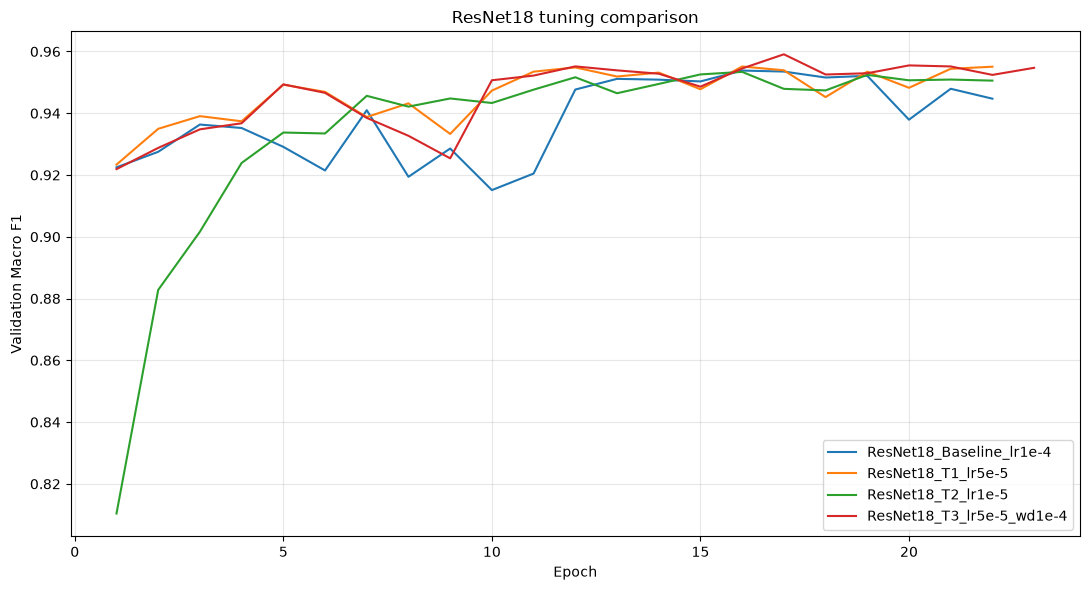

In [12]:
histories=[]
baseline_history_path=RESULT_DIR/'ResNet18_NoAug_history.csv'
if baseline_history_path.exists():
    h=pd.read_csv(baseline_history_path); h['name']='ResNet18_Baseline_lr1e-4'; histories.append(h)
for cfg in TUNING_CONFIGS:
    histories.append(pd.read_csv(RESULT_DIR/f"{cfg['name']}_history.csv"))
plt.figure(figsize=(11,6))
for h in histories: plt.plot(h.epoch,h.val_macro_f1,label=h['name'].iloc[0])
plt.xlabel('Epoch'); plt.ylabel('Validation Macro F1'); plt.title('ResNet18 tuning comparison')
plt.grid(alpha=.3); plt.legend(); plt.tight_layout()
plt.savefig(RESULT_DIR/'ResNet18_tuning_curves.png',dpi=150,bbox_inches='tight'); plt.show()


## 9. 최종 선택 모델 Test 평가

위 Validation 비교가 완료되고 설정을 확정한 뒤 한 번만 실행합니다.


In [13]:
selected_model=ResNet18(NUM_CLASSES).to(device)
selected_ckpt=torch.load(Path(best_row['checkpoint_path']),map_location=device)
selected_model.load_state_dict(selected_ckpt['model_state_dict'])
test_result=evaluate(selected_model,test_loader,nn.CrossEntropyLoss())
print('Selected:',best_row['name'])
print(f"Test Accuracy: {test_result['accuracy']:.4f}")
print(f"Test Balanced Accuracy: {test_result['balanced_accuracy']:.4f}")
print(f"Test Macro F1: {test_result['macro_f1']:.4f}")

report=pd.DataFrame(classification_report(test_result['targets'],test_result['preds'],labels=range(NUM_CLASSES),
                    target_names=class_names,output_dict=True,zero_division=0)).T
report.to_csv(RESULT_DIR/'ResNet18_tuned_classification_report.csv'); display(report)

summary={'selected_config':str(best_row['name']),'best_epoch':int(selected_ckpt['best_epoch']),
         'val_macro_f1':float(best_row['val_macro_f1']),'test_accuracy':float(test_result['accuracy']),
         'test_balanced_accuracy':float(test_result['balanced_accuracy']),'test_macro_f1':float(test_result['macro_f1'])}
with open(RESULT_DIR/'ResNet18_tuning_summary.json','w',encoding='utf-8') as f: json.dump(summary,f,ensure_ascii=False,indent=2)


  0%|          | 0/73 [00:00<?, ?it/s]

Selected: ResNet18_T3_lr5e-5_wd1e-4
Test Accuracy: 0.9729
Test Balanced Accuracy: 0.9561
Test Macro F1: 0.9576


,precision,recall,f1-score,support
battery,0.992958,0.992958,0.992958,142.000000
biological,0.953947,0.979730,0.966667,148.000000
brown-glass,1.000000,0.934783,0.966292,92.000000
cardboard,0.977273,0.977273,0.977273,132.000000
clothes,0.998737,0.998737,0.998737,792.000000
green-glass,0.936842,0.967391,0.951872,92.000000
metal,0.914530,0.938596,0.926407,114.000000
paper,0.974684,0.980892,0.977778,157.000000
plastic,0.917355,0.860465,0.888000,129.000000
shoes,0.980583,1.000000,0.990196,303.000000


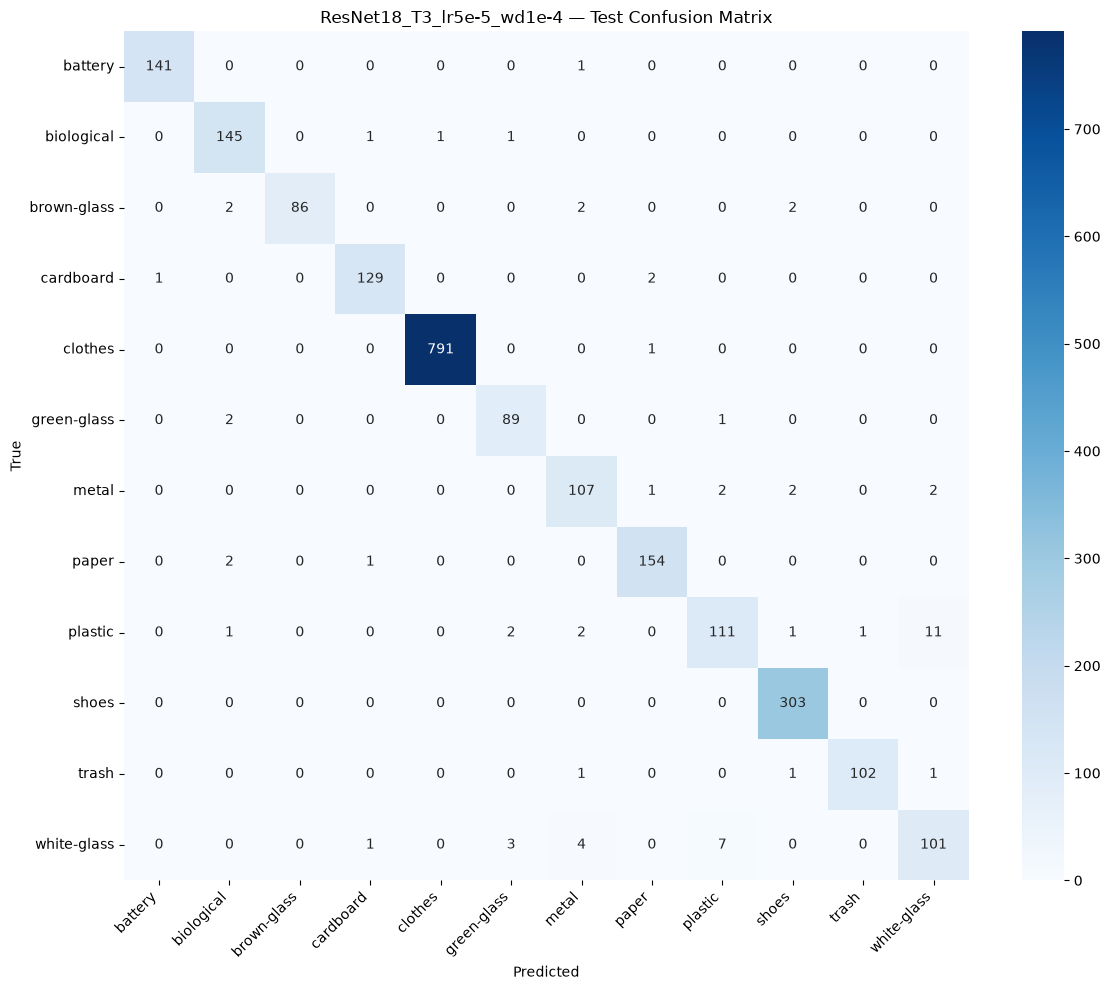

In [14]:
cm=confusion_matrix(test_result['targets'],test_result['preds'],labels=range(NUM_CLASSES))
plt.figure(figsize=(12,10)); sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f"{best_row['name']} — Test Confusion Matrix")
plt.xticks(rotation=45,ha='right'); plt.tight_layout()
plt.savefig(RESULT_DIR/'ResNet18_tuned_confusion_matrix.png',dpi=150,bbox_inches='tight'); plt.show()


## 해석 기준

- 학습률을 낮췄을 때 Macro F1이 개선됐는지 확인합니다.
- T3가 T1보다 높다면 weight decay가 일반화에 도움이 된 것입니다.
- 점수 차이가 매우 작으면 복잡성을 늘리지 않고 기존 `1e-4` 설정을 유지하는 것도 타당합니다.
- 이 노트북은 하이퍼파라미터 탐색이므로 증강 가설검정과 별개의 실험입니다.
